---

## 1) MNIST dataset

**MNIST** is used because it's:

- easy to visualize,
- large enough to see realistic evaluation issues,
- naturally supports binary, multiclass, and beyond.


In [1]:
# %%
# Core imports
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml


In [2]:
# %%
# Fetch MNIST (may download from OpenML the first time)
mnist = fetch_openml("mnist_784", as_frame=False)

X, y = mnist.data, mnist.target
y = y.astype(np.uint8)

X.shape, y.shape


((70000, 784), (70000,))

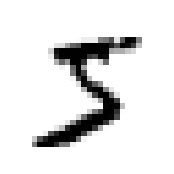

np.uint8(5)

In [3]:
# %%
# Quick visualization helper
def plot_digit(image_data):
    image = image_data.reshape(28, 28)
    plt.imshow(image, cmap="binary")
    plt.axis("off")

plt.figure(figsize=(2,2))
plot_digit(X[0])
plt.show()

y[0]


In [4]:
# %%
# Train/test split (book uses first 60k for train, last 10k for test)
X_train, X_test = X[:60000], X[60000:]
y_train, y_test = y[:60000], y[60000:]

# Shuffle training set (important for some CV splitters and SGD)
shuffle_idx = np.random.permutation(60000)
X_train, y_train = X_train[shuffle_idx], y_train[shuffle_idx]


---

## 2) Training a binary classifier (a “5-detector”)

We starts with a simple binary task:

- **positive class**: “is digit 5” and **negative class**: “not 5”


In [5]:
# %%
from sklearn.linear_model import SGDClassifier

y_train_5 = (y_train == 5)
y_test_5 = (y_test == 5)

sgd_clf = SGDClassifier(random_state=42)
sgd_clf.fit(X_train, y_train_5)

# Test a single prediction
some_digit = X[0]
sgd_clf.predict([some_digit])[0], y[0]


(np.True_, np.uint8(5))

In [6]:
# %%
# Decision score: higher => more likely "5"
sgd_clf.decision_function([some_digit])[0]


np.float64(3834.427448359816)

---

## 3) Performance measures: why accuracy can lie

On imbalanced problems (like “detect 5” vs “not 5”), a model can look “good” with accuracy while being useless.


In [7]:
# %%
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.base import clone

# CV accuracy for the 5-detector
cross_val_score(sgd_clf, X_train, y_train_5, cv=3, scoring="accuracy")


array([0.9638 , 0.96605, 0.9661 ])

In [8]:
# %%
# A dummy classifier that always predicts "not 5" can get very high accuracy (because 5s are ~10%)
from sklearn.dummy import DummyClassifier

dummy_clf = DummyClassifier(strategy="most_frequent")
cross_val_score(dummy_clf, X_train, y_train_5, cv=3, scoring="accuracy")


array([0.90965, 0.90965, 0.90965])

---

## 4) Confusion matrix: the evaluation “accounting sheet”


In [9]:
# %%
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import confusion_matrix

y_train_pred = cross_val_predict(sgd_clf, X_train, y_train_5, cv=3)
confusion_matrix(y_train_5, y_train_pred)


array([[53816,   763],
       [ 1318,  4103]])

---

## 5) Precision, recall, F1: the core trio


In [10]:
# %%
from sklearn.metrics import precision_score, recall_score, f1_score

precision_score(y_train_5, y_train_pred), recall_score(y_train_5, y_train_pred), f1_score(y_train_5, y_train_pred)


(0.8431976983148376, 0.7568714259361742, 0.7977058423252649)

---

## 6) The precision/recall trade-off (threshold tuning)


In [11]:
# %%
from sklearn.metrics import precision_recall_curve

# Get decision scores (not predicted labels)
y_scores = cross_val_predict(sgd_clf, X_train, y_train_5, cv=3, method="decision_function")

precisions, recalls, thresholds = precision_recall_curve(y_train_5, y_scores)

precisions[:5], recalls[:5], thresholds[:5]


(array([0.09035   , 0.09035151, 0.09035301, 0.09035452, 0.09035602]),
 array([1., 1., 1., 1., 1.]),
 array([-157106.39088016, -154709.04709248, -147273.86747775,
        -143367.0882025 , -142220.12275182]))

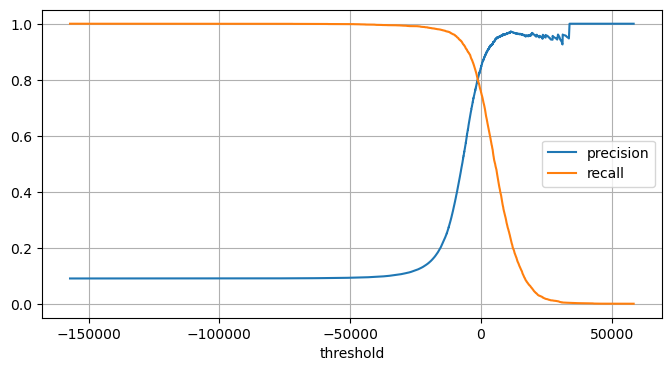

In [12]:
# %%
# Plot precision & recall vs threshold
plt.figure(figsize=(8,4))
plt.plot(thresholds, precisions[:-1], label="precision")
plt.plot(thresholds, recalls[:-1], label="recall")
plt.xlabel("threshold")
plt.legend()
plt.grid(True)
plt.show()


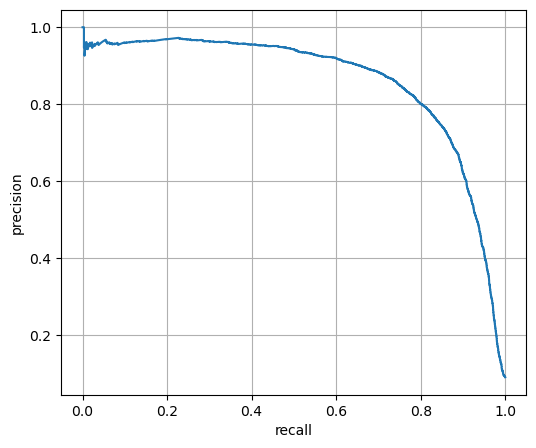

In [13]:
# %%
# Plot precision vs recall (PR curve)
plt.figure(figsize=(6,5))
plt.plot(recalls, precisions)
plt.xlabel("recall")
plt.ylabel("precision")
plt.grid(True)
plt.show()


In [14]:
# %%
# Pick a threshold that yields ~90% precision (example)
# (You may need to adjust based on your run; the exact number varies with randomness/version.)
target_precision = 0.90
idx = np.argmax(precisions >= target_precision)  # first index reaching target
chosen_threshold = thresholds[max(idx - 1, 0)]
chosen_threshold


np.float64(2246.3405238493715)

In [15]:
# %%
# Apply chosen threshold
y_train_pred_90 = (y_scores >= chosen_threshold)

precision_score(y_train_5, y_train_pred_90), recall_score(y_train_5, y_train_pred_90)


(0.8998738965952081, 0.6581811473897805)

---

## 7) ROC curve (and ROC AUC)


In [16]:
# %%
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, roc_thresholds = roc_curve(y_train_5, y_scores)
auc = roc_auc_score(y_train_5, y_scores)
auc


0.9684804980643724

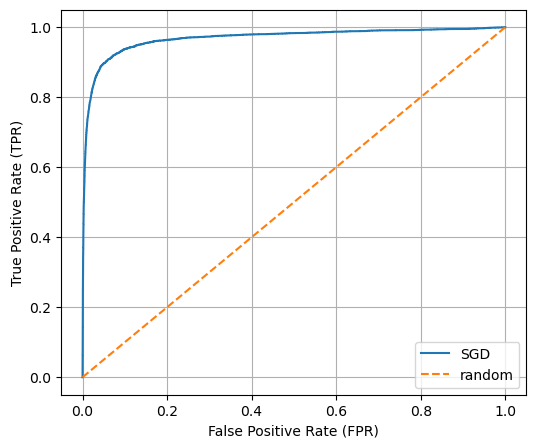

In [17]:
# %%
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label="SGD")
plt.plot([0, 1], [0, 1], linestyle="--", label="random")
plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.legend()
plt.grid(True)
plt.show()


---

## 8) Comparing classifiers: probabilities vs decision scores


In [18]:
# %%
from sklearn.ensemble import RandomForestClassifier

forest_clf = RandomForestClassifier(random_state=42, n_estimators=200, n_jobs=-1)
# Probabilities as scores
y_probas_forest = cross_val_predict(forest_clf, X_train, y_train_5, cv=3, method="predict_proba")
y_scores_forest = y_probas_forest[:, 1]

fpr_forest, tpr_forest, _ = roc_curve(y_train_5, y_scores_forest)
auc_forest = roc_auc_score(y_train_5, y_scores_forest)

auc, auc_forest


(0.9684804980643724, 0.9986089408792108)

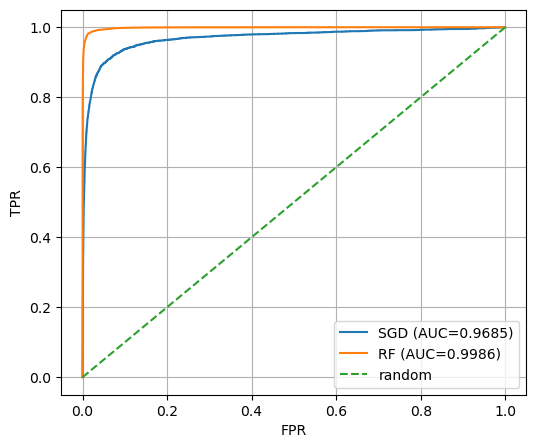

In [19]:
# %%
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"SGD (AUC={auc:.4f})")
plt.plot(fpr_forest, tpr_forest, label=f"RF (AUC={auc_forest:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="random")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.legend()
plt.grid(True)
plt.show()


---

## 9) Multiclass classification (10 digits)


In [ ]:
# %%
# Train an SGD multiclass classifier (OvR by default for linear models)
sgd_clf_multi = SGDClassifier(random_state=42)
sgd_clf_multi.fit(X_train, y_train)

sgd_clf_multi.predict([some_digit])[0], y[0]


In [ ]:
# %%
# Inspect decision scores (one score per class)
scores = sgd_clf_multi.decision_function([some_digit])
scores.shape, scores.argmax(), sgd_clf_multi.classes_[scores.argmax()]


In [ ]:
# %%
# Baseline accuracy with CV
cross_val_score(sgd_clf_multi, X_train, y_train, cv=3, scoring="accuracy")


In [ ]:
# %%
# Scaling usually helps SGD a lot
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

sgd_scaled = make_pipeline(StandardScaler(), SGDClassifier(random_state=42))
cross_val_score(sgd_scaled, X_train, y_train, cv=3, scoring="accuracy")


---

## 10) Error analysis: learn from mistakes, not just scores


In [ ]:
# %%
from sklearn.metrics import ConfusionMatrixDisplay

y_train_pred_multi = cross_val_predict(sgd_scaled, X_train, y_train, cv=3)

cm = confusion_matrix(y_train, y_train_pred_multi)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
plt.figure(figsize=(7,7))
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion matrix (scaled SGD)")
plt.show()


In [ ]:
# %%
# Normalize to show relative error rates
cm_norm = cm.astype(np.float64) / cm.sum(axis=1, keepdims=True)
np.fill_diagonal(cm_norm, 0.0)

plt.figure(figsize=(7,7))
plt.imshow(cm_norm, cmap="Blues")
plt.title("Normalized confusion matrix (errors only)")
plt.axis("off")
plt.show()


In [ ]:
# %%
# Visualize some misclassified digits
# We'll fit once on full training set for convenience
sgd_scaled.fit(X_train, y_train)
y_train_pred_full = sgd_scaled.predict(X_train)

mis_idx = np.where(y_train_pred_full != y_train)[0]
len(mis_idx)


In [ ]:
# %%
# Show a grid of mistakes (true label vs predicted)
def plot_digits(instances, images_per_row=10, **options):
    size = 28
    images = [instance.reshape(size, size) for instance in instances]
    n_rows = (len(instances) - 1) // images_per_row + 1
    row_images = []
    n_empty = n_rows * images_per_row - len(instances)
    images.append(np.zeros((size, size * n_empty)))
    for row in range(n_rows):
        rimages = images[row * images_per_row : (row + 1) * images_per_row]
        row_images.append(np.concatenate(rimages, axis=1))
    image = np.concatenate(row_images, axis=0)
    plt.imshow(image, cmap="binary", **options)
    plt.axis("off")

n_show = 40
samples = X_train[mis_idx[:n_show]]
true_labels = y_train[mis_idx[:n_show]]
pred_labels = y_train_pred_full[mis_idx[:n_show]]

plt.figure(figsize=(10,4))
plot_digits(samples, images_per_row=10)
plt.show()

list(zip(true_labels[:10], pred_labels[:10]))


---

## 11) Multilabel and multioutput classification

- **multilabel**: one instance can have multiple labels simultaneously (e.g., “digit is odd” + “digit is ≥5”).
- **multioutput**: predict multiple outputs at once (often multiple labels, possibly of different types).


In [ ]:
# %%
# Multilabel example: is the digit large? is it odd?
from sklearn.neighbors import KNeighborsClassifier

y_train_large = (y_train >= 7)
y_train_odd = (y_train % 2 == 1)
y_multilabel = np.c_[y_train_large, y_train_odd]

knn_clf = KNeighborsClassifier()
knn_clf.fit(X_train, y_multilabel)

knn_clf.predict([some_digit])


In [ ]:
# %%
# Multioutput example: denoising images (predict 784 pixel values)
rng = np.random.RandomState(42)

noise = rng.randint(0, 100, (len(X_train), 784))
X_train_mod = X_train + noise
noise = rng.randint(0, 100, (len(X_test), 784))
X_test_mod = X_test + noise

y_train_mod = X_train
y_test_mod = X_test

knn_denoise = KNeighborsClassifier()
knn_denoise.fit(X_train_mod, y_train_mod)

clean_digit = knn_denoise.predict([X_test_mod[0]])


In [ ]:
# %%
# Compare noisy vs denoised visually
plt.figure(figsize=(6,2))

plt.subplot(1, 3, 1)
plot_digit(X_test[0])
plt.title("Original")
plt.axis("off")

plt.subplot(1, 3, 2)
plot_digit(X_test_mod[0])
plt.title("Noisy")
plt.axis("off")

plt.subplot(1, 3, 3)
plot_digit(clean_digit[0])
plt.title("Denoised")
plt.axis("off")

plt.tight_layout()
plt.show()


---

## End

You now have a runnable notebook that matches the blog sections:
- Binary “5-detector” + evaluation
- Threshold tuning + PR/ROC curves
- Multiclass classification + scaling
- Error analysis
- Multilabel + multioutput demos
